In [3]:
import os
os.chdir('/kaggle/working')

!git clone https://github.com/basiaseweryn/generative-models-cat-images.git

Cloning into 'generative-models-cat-images'...
remote: Enumerating objects: 40, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 40 (delta 16), reused 19 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (40/40), 77.19 KiB | 5.94 MiB/s, done.
Resolving deltas: 100% (16/16), done.


In [4]:
%cd /kaggle/working/generative-models-cat-images

/kaggle/working/generative-models-cat-images


In [12]:
!git pull 

Already up to date.


In [5]:
import sys
import os
import os


PROJECT_ROOT = "/kaggle/working/generative-models-cat-images" 

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

UTILS_PATH = os.path.join(PROJECT_ROOT, "utils")
if UTILS_PATH not in sys.path:
    sys.path.insert(0, UTILS_PATH)

print(f"project root added: {PROJECT_ROOT}")
print(f"utils folder added: {UTILS_PATH}")
print(f"available files: {os.listdir(PROJECT_ROOT)}")

project root added: /kaggle/working/generative-models-cat-images
utils folder added: /kaggle/working/generative-models-cat-images/utils
available files: ['README.md', 'requirements.txt', 'DL_project_3_plan.pdf', 'experiments.ipynb', 'utils', '.git', 'LICENSE', '.gitignore']


In [6]:
import os
import torch
import torch.optim as optim
from tqdm import tqdm

from utils.config import (
    EXPERIMENTS,
    FID_NUM_SAMPLES,
    RANDOM_SEED,
    STAGE_1_SCENARIOS,
    STAGE_2_SCENARIOS,
    STAGE_4_SCENARIOS,
    TRAINED_MODELS_DIR,
    seed_everything,
)
from utils.data_utils import get_dataloader
from utils.models import get_model, sample_dcgan, sample_vae, vae_loss
from utils.evaluation_utils import (
    compare_cats_vs_cats_dogs,
    compare_fid_scenarios,
    compare_mode_collapse_scenarios,
    denormalize_dcgan,
    evaluate_fid_scenario,
    generate_candidate_grid,
    interpolate_between_latents,
    load_trained_model,
    output_path,
    print_fid_table,
    save_checkpoint,
    save_interpolation_grid,
    save_latent_codes,
    save_sample_grid,
    show_image_grid,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed_everything(RANDOM_SEED)
print("Device:", device)

Random seed set to 42
Device: cuda


## Training loops

## Stage 1 — Baseline training

Train both models (run this cell twice with different `SCENARIO`, or run both in sequence).

In [7]:
def train_vae_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss, total_recon, total_kl = 0.0, 0.0, 0.0
    for batch in tqdm(loader, leave=False):
        if isinstance(batch, (list, tuple)):
            batch = batch[0]
        batch = batch.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model(batch)
        loss, recon_l, kl_l = vae_loss(recon, batch, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_recon += recon_l.item()
        total_kl += kl_l.item()
    n = len(loader)
    return total_loss / n, total_recon / n, total_kl / n


def train_dcgan_one_epoch(model, loader, opt_g, opt_d, device, config):
    model.train()
    n_critic = config.get("n_critic", 1)
    noise_std = config.get("instance_noise_std", 0.0)
    latent_dim = config.get("latent_dim", 128)
    criterion = torch.nn.BCELoss()
    g_losses, d_losses = [], []

    for batch in tqdm(loader, leave=False):
        if isinstance(batch, (list, tuple)):
            batch = batch[0]
        real = batch.to(device)
        bsz = real.size(0)
        real_labels = torch.ones(bsz, 1, device=device)
        fake_labels = torch.zeros(bsz, 1, device=device)

        for _ in range(n_critic):
            opt_d.zero_grad()
            z = torch.randn(bsz, latent_dim, device=device)
            fake = model.generator(z).detach()
            real_in = real + torch.randn_like(real) * noise_std if noise_std > 0 else real
            fake_in = fake + torch.randn_like(fake) * noise_std if noise_std > 0 else fake
            loss_d = (
                criterion(model.discriminator(real_in), real_labels)
                + criterion(model.discriminator(fake_in), fake_labels)
            ) * 0.5
            loss_d.backward()
            opt_d.step()
            d_losses.append(loss_d.item())

        opt_g.zero_grad()
        z = torch.randn(bsz, latent_dim, device=device)
        fake = model.generator(z)
        loss_g = criterion(model.discriminator(fake), real_labels)
        loss_g.backward()
        opt_g.step()
        g_losses.append(loss_g.item())

    return sum(g_losses) / len(g_losses), sum(d_losses) / len(d_losses)


def run_training(scenario_name: str):
    config = EXPERIMENTS[scenario_name].copy()
    loader = get_dataloader(config)
    model = get_model(config["model"], config).to(device)
    save_dir = os.path.join(TRAINED_MODELS_DIR, scenario_name)
    os.makedirs(save_dir, exist_ok=True)
    history = {"epoch": [], "loss": [], "recon": [], "kl": [], "g_loss": [], "d_loss": []}

    if config["model"] == "vae":
        optimizer = optim.Adam(model.parameters(), lr=config["lr"])
        for epoch in range(1, config["epochs"] + 1):
            loss, recon, kl = train_vae_one_epoch(model, loader, optimizer, device)
            history["epoch"].append(epoch)
            history["loss"].append(loss)
            history["recon"].append(recon)
            history["kl"].append(kl)
            print(f"Epoch {epoch}/{config['epochs']} | loss={loss:.4f} recon={recon:.4f} kl={kl:.4f}")
            if epoch % 10 == 0 or epoch == config["epochs"]:
                samples = sample_vae(model, 64, device)
                save_sample_grid(samples, os.path.join(save_dir, f"samples_epoch_{epoch}.png"))
        save_checkpoint(os.path.join(save_dir, "model.pth"), model, optimizer, config["epochs"], history, config)
        return model, history, config

    opt_g = optim.Adam(model.generator.parameters(), lr=config["lr"], betas=(0.5, 0.999))
    opt_d = optim.Adam(model.discriminator.parameters(), lr=config["lr"], betas=(0.5, 0.999))
    for epoch in range(1, config["epochs"] + 1):
        g_loss, d_loss = train_dcgan_one_epoch(model, loader, opt_g, opt_d, device, config)
        history["epoch"].append(epoch)
        history["g_loss"].append(g_loss)
        history["d_loss"].append(d_loss)
        print(f"Epoch {epoch}/{config['epochs']} | G={g_loss:.4f} D={d_loss:.4f}")
        if epoch % 10 == 0 or epoch == config["epochs"]:
            samples = sample_dcgan(model.generator, 64, config["latent_dim"], device)
            save_sample_grid(denormalize_dcgan(samples), os.path.join(save_dir, f"samples_epoch_{epoch}.png"))
    torch.save(
        {"epoch": config["epochs"], "model_state_dict": model.state_dict(),
         "opt_g": opt_g.state_dict(), "opt_d": opt_d.state_dict(), "history": history, "config": config},
        os.path.join(save_dir, "model.pth"),
    )
    return model, history, config

In [6]:
SCENARIO = "stage_1_vae"  

model, history, config = run_training(SCENARIO) 

Epoch 1/50 | loss=7578.3084 recon=7431.4850 kl=146.8233


Epoch 2/50 | loss=7137.0783 recon=7043.9793 kl=93.0991


Epoch 3/50 | loss=7060.2964 recon=6963.9881 kl=96.3083


Epoch 4/50 | loss=6988.5751 recon=6884.9877 kl=103.5874


Epoch 5/50 | loss=6955.5427 recon=6849.1739 kl=106.3687


...

Epoch 46/50 | loss=6829.4796 recon=6701.4148 kl=128.0648


Epoch 47/50 | loss=6828.1698 recon=6699.9001 kl=128.2697


Epoch 48/50 | loss=6828.0285 recon=6699.6502 kl=128.3783


Epoch 49/50 | loss=6827.4826 recon=6698.9297 kl=128.5529


Epoch 50/50 | loss=6825.7181 recon=6697.2470 kl=128.4711
Saved grid -> ./trained_models/stage_1_vae/samples_epoch_50.png


In [8]:
SCENARIO = "stage_1_dcgan"  

model, history, config = run_training(SCENARIO)

Epoch 1/50 | G=7.3356 D=0.3202


Epoch 2/50 | G=3.2543 D=0.3696


Epoch 3/50 | G=3.3958 D=0.3569


Epoch 4/50 | G=3.3909 D=0.3254


Epoch 5/50 | G=3.1804 D=0.3559


...

Epoch 46/50 | G=3.5043 D=0.2363


Epoch 47/50 | G=3.3699 D=0.2384


Epoch 48/50 | G=3.4588 D=0.0928


Epoch 49/50 | G=3.8343 D=0.0697


Epoch 50/50 | G=3.4204 D=0.4716
Saved grid -> ./trained_models/stage_1_dcgan/samples_epoch_50.png


## Quantitative comparison — FID (VAE vs DCGAN)

Uses **2000** real/fake samples by default (`FID_NUM_SAMPLES` in config). Lower FID = better.

In [9]:
fid_rows_stage1 = compare_fid_scenarios(
    STAGE_1_SCENARIOS,
    device,
    max_samples=FID_NUM_SAMPLES,
    save_csv=output_path("reports", "fid_stage1.csv"),
)
print_fid_table(fid_rows_stage1)

FID [stage_1_vae] (2000 samples): 195.24
FID [stage_1_dcgan] (2000 samples): 148.53
Saved FID table -> ./outputs/reports/fid_stage1.csv
scenario                         model  lr         z     bs         FID
-----------------------------------------------------------------------
stage_1_vae                      vae    0.001      128   128     195.24
stage_1_dcgan                    dcgan  0.0002     128   128     148.53


## Qualitative assessment — sample grid

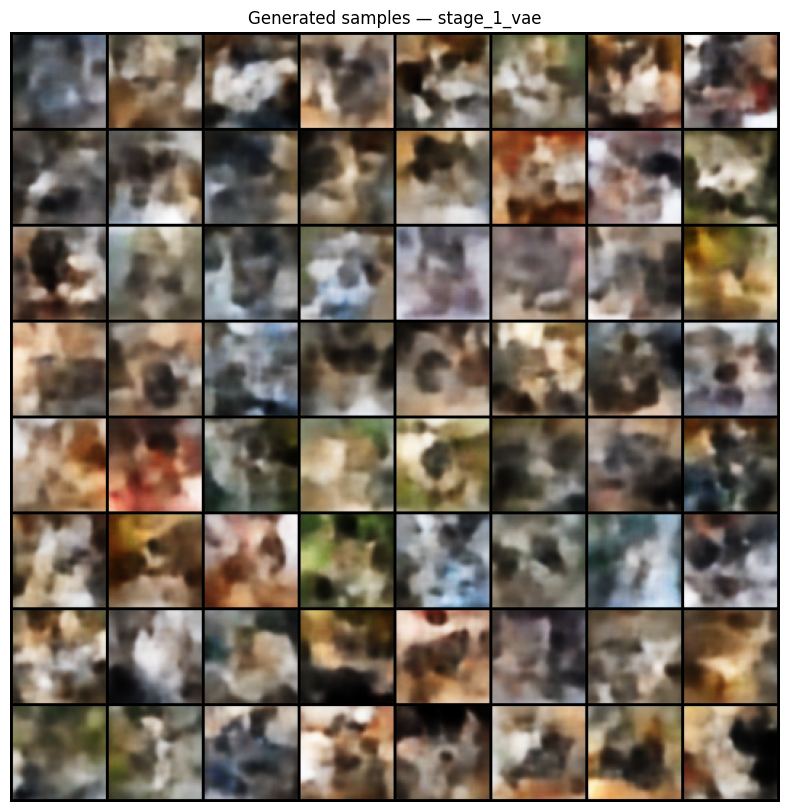

Saved grid -> ./outputs/stage_1_vae/qualitative_grid.png


In [10]:
SCENARIO = "stage_1_vae" 

model, config, _ = load_trained_model(SCENARIO, device)
display_imgs, latents, _ = generate_candidate_grid(model, config, device, num_candidates=64, seed=42)
show_image_grid(display_imgs, title=f"Generated samples — {SCENARIO}", nrow=8)
save_sample_grid(display_imgs, output_path(SCENARIO, "qualitative_grid.png"), nrow=8)

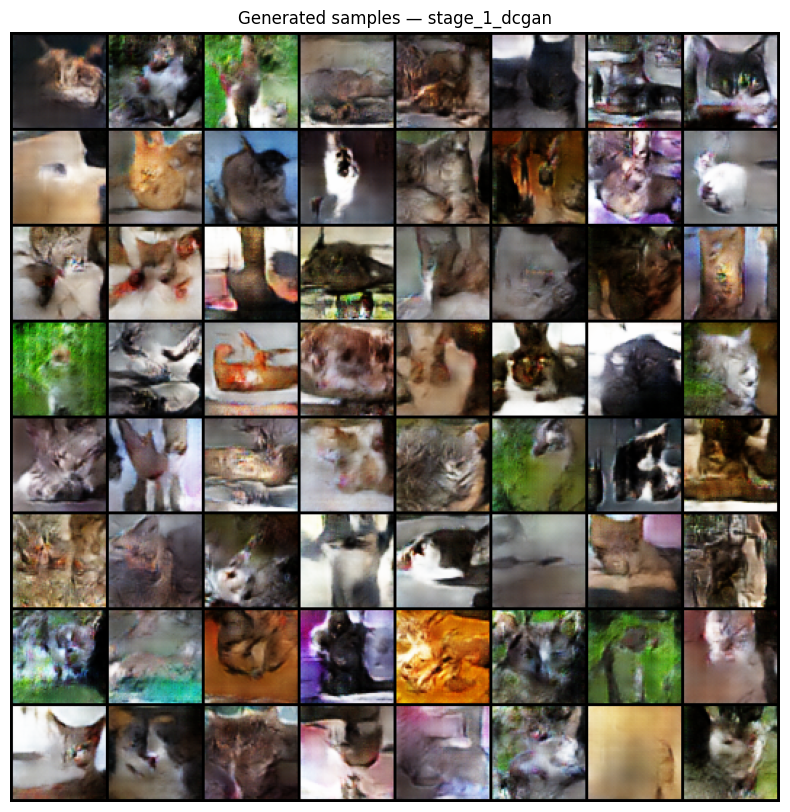

Saved grid -> ./outputs/stage_1_dcgan/qualitative_grid.png


In [11]:
SCENARIO = "stage_1_dcgan" 

model, config, _ = load_trained_model(SCENARIO, device)
display_imgs, latents, _ = generate_candidate_grid(model, config, device, num_candidates=64, seed=42)
show_image_grid(display_imgs, title=f"Generated samples — {SCENARIO}", nrow=8)
save_sample_grid(display_imgs, output_path(SCENARIO, "qualitative_grid.png"), nrow=8)

## Stage 2 — Hyperparameter experiments

Train each `stage_2_*` scenario (subset of data for speed), then run the FID table below.

In [8]:
for name in STAGE_2_SCENARIOS:
    if name == "stage_2_vae" or name == "stage_2_vae_lr_1e-4":
        continue
    run_training(name)

Using subset: 4998 / 19994 images (25%)


Epoch 1/30 | loss=7776.4416 recon=7686.9898 kl=89.4518


Epoch 2/30 | loss=7250.8092 recon=7166.3345 kl=84.4747


Epoch 3/30 | loss=7147.4042 recon=7059.0323 kl=88.3719


Epoch 4/30 | loss=7102.6639 recon=7011.7178 kl=90.9462


...

Epoch 26/30 | G=3.3666 D=0.2694


Epoch 27/30 | G=3.9017 D=0.2330


Epoch 28/30 | G=3.9655 D=0.2849


Epoch 29/30 | G=3.9424 D=0.2498


Epoch 30/30 | G=4.0143 D=0.2428
Saved grid -> ./trained_models/stage_2_dcgan_batch_64/samples_epoch_30.png


In [9]:
fid_rows_stage2 = compare_fid_scenarios(
    STAGE_2_SCENARIOS,
    device,
    max_samples=FID_NUM_SAMPLES,
    save_csv=output_path("reports", "fid_stage2_hyperparams.csv"),
)
print_fid_table(fid_rows_stage2)



FileNotFoundError: No checkpoint at ./trained_models/stage_2_vae_lr_1e-4/model.pth. Train 'stage_2_vae_lr_1e-4' first.

## Stage 3 — Latent interpolation (10 images)

1. Generate a candidate grid  
2. Pick two indices (`IDX_A`, `IDX_B`)  
3. Save their latent vectors  
4. Linearly interpolate → **8 intermediate** + **2 endpoints** = 10 images  

**Report discussion:** Is the transition smooth? What does that imply about the latent space?

In [ ]:
SCENARIO = "stage_1_dcgan"  # best scenario so far

model, config, _ = load_trained_model(SCENARIO, device)
display_imgs, latents, _ = generate_candidate_grid(model, config, device, num_candidates=64, seed=123)
show_image_grid(display_imgs, title="Pick two images — note their indices", nrow=8)

# Change these after inspecting the grid above
IDX_A = 3
IDX_B = 47

z_a = latents[IDX_A].clone()
z_b = latents[IDX_B].clone()
save_latent_codes(z_a, z_b, output_path(SCENARIO, "interpolation_latents.pth"))

print("z_a shape:", z_a.shape)
print("z_b shape:", z_b.shape)
print("z_a (first 8 values):", z_a[:8].cpu().numpy())

In [ ]:
interp_display, interp_raw, is_dcgan = interpolate_between_latents(
    model, config, z_a, z_b, device, num_steps=8
)

path = output_path(SCENARIO, "interpolation_10_images.png")
save_interpolation_grid(interp_raw, path, is_dcgan=is_dcgan)
show_image_grid(interp_display, title=f"Interpolation: idx {IDX_A} -> {IDX_B} (10 images)", nrow=10)

# Endpoint-only view (the two originally selected generations)
endpoints = torch.stack([interp_display[0], interp_display[-1]])
show_image_grid(endpoints, title="Endpoints (selected generated images)", nrow=2)

## Stage 4 — Mode collapse

If `likely_mode_collapse` is True, retrain with a `stage_4_*` scenario and compare again.

In [ ]:
# Check baseline DCGAN (train stage_4_* if collapse is likely)
collapse_results = compare_mode_collapse_scenarios(STAGE_4_SCENARIOS, device)

# Optional: train mitigations first
# run_training("stage_4_dcgan_n_critic_5")
# run_training("stage_4_dcgan_instance_noise")

In [ ]:
# FID after mitigation — compare to stage_1_dcgan
fid_rows_stage4 = compare_fid_scenarios(
    STAGE_4_SCENARIOS,
    device,
    max_samples=FID_NUM_SAMPLES,
    save_csv=output_path("reports", "fid_stage4_mode_collapse.csv"),
)
print_fid_table(fid_rows_stage4)

## Stage 5 — Cats + dogs vs cats only

Exploratory: do samples look like distinct cats/dogs or blends? Compare FID and grids.

In [ ]:
# Train after picking your best architecture from stage 1–2:
# run_training("stage_5_dcgan_cats_dogs")  # or stage_5_vae_cats_dogs
# run_training("stage_1_dcgan")  # cats-only baseline if not already trained

In [ ]:
SCENARIO_CATS_ONLY = "stage_1_dcgan"
SCENARIO_MIXED = "stage_5_dcgan_cats_dogs"

summary, imgs_cat, imgs_mix = compare_cats_vs_cats_dogs(
    SCENARIO_CATS_ONLY,
    SCENARIO_MIXED,
    device,
    num_samples=64,
)

show_image_grid(imgs_cat, title=f"Cats only — {SCENARIO_CATS_ONLY}", nrow=8)
show_image_grid(imgs_mix, title=f"Cats + dogs — {SCENARIO_MIXED}", nrow=8)

# Report: discuss whether outputs are class-distinct or blended (exploratory).

## Additional findings (for your report)

Use this checklist after experiments:
- VAE vs DCGAN: FID table + sharpness/blur in sample grids
- Best hyperparameters from stage 2 CSV
- Interpolation smoothness (stage 3)
- Mode collapse: diversity scores + whether stage 4 helped
- Cats+dogs: distinct classes vs chimera images
- Compute strategy: 64×64, `subset_ratio`, epoch counts